# <img src="./logo_UTN.svg" align="right" width="150" /> 

#### Teoría de Circuitos II

# Tarea Semanal 4

Autor: Lopez Cruz Juan Carlos.

# Introducción

A partir de la siguiente plantilla, sabiendo que en banda de paso la respuesta es **Chebyshev**:

<img src="./plantilla_ts4.png" /> 

* $f_0 = 22kHz; f_{s1} = 17kHz; f_{s2} = 36kHz$
* $Q = 5$ siendo $\omega1 \cdot \omega2 = \omega_0^2; \omega2 - \omega1 = \frac{\omega_0}{Q}$

## Items a tratar de la platilla:

1. Obtener la plantilla de atenuación normalizada en frecuencia.  Indicar los valores de $\alpha_{max}$ y de $\alpha_{min}$ 

2. Obtener la función transferencia normalizada del prototipo pasa bajo que satisfaga el requerimiento del filtro pasa banda.

3. Aplicar el núcleo de transformación pasa banda y obtener la transferencia. Factorizar convenientemente para expresar en SOS.

4. Realizar la simulación numérica en python. Graficar la respuesta en frecuencia del filtro pasa banda total, y las de las SOS. 

## Items Bonus(aun no estan hechos, estan en proceso):

1. Simulación Circuital del filtro pasa banda implementado mediante secciones pasivas separadas por seguidores de tensión activos.

2. Dado el pasa bajo hallado en 2)  aplicar el núcleo de transformación pasa altos y obtener la transferencia.  

3. Dado el pasa bajo hallado en 2) , implementarlo con pasivos y aplicar la transformación de Bruton. Obtener el valor numérico de D del FDNR siendo $Z_{FDNR} = \frac{1}{s^2 \cdot D}$ 

## Resolucion:

### Normalizacion de la plantilla

Primeramente procedemos a normalizar nuestra plantilla, para ello tomamos como norma de frecuencia a $\Omega_\omega = \omega_o = 2\pi f_o$, al estar en una plantilla pasa banda sabemos que $\omega_{p1}$ y $\omega_{p2}$ al transformalas al filtro pasa bajo estas seran de modulo 1, por lo que solo queda normalizar las frecuencias de corte:

* $\omega_{o_n} = 1$
* $\omega_{s1_n} = \frac{\omega_s2}{\omega_o} = \frac{f_s1}{f_o} = \frac{17KHz}{22KHz} = 0.772$
* $\omega_{s2_n} = \frac{\omega_s2}{\omega_o} = \frac{f_s2}{f_o} = \frac{36KHz}{22KHz} = 1.63$

### Transformacion de la plantilla

Ahora procedemor a transformar nuestra plantilla pasa banda a una pasa bajos, para ello calculamos nuestras $\omega_{p_{LP}}$, $\omega_{s1_{LP}}$ y $\omega_{s1_{LP}}$ teniendo en cuenta el siguiente nucleo de transformacion.

$$
K(w) = \frac{\omega_o}{B} \frac{w^2 - w_0^2}{w} = Q \cdot \frac{w^2 - 1}{w}
$$

Donde $B$ es el ancho de banda, el cual puede calcularse mediante $Q = \frac{\omega_o}{B}$, siendo entonces $B = 0.2$, ya con esta consideracion en cuenta procedemos a calcular.

* $\omega_{p_{LP}} =  1$
* $\omega_{s1_{LP}} = Q \cdot \frac{\omega_{s1_n}^2 - 1}{\omega_{s1_n}} = 5 \cdot \frac{0.772^2 - 1}{0.772} = 2.616$
* $\omega_{s2_{LP}} = Q \cdot \frac{\omega_{s2_n}^2 - 1}{\omega_{s2_n}} = 5 \cdot \frac{1.63^2 - 1}{1.63} = 5.082$

### Calculo de $\xi$ y n

Ya normalizada la plantilla procedemos a calcular $\xi$ y n de nuestra plantilla pasa bajos

$$
\xi^2 = 10^{\alpha_{max} \cdot 0.1} - 1 = 10^{0.5 \cdot 0.1} - 1 = 0.122 \Rightarrow \xi = \sqrt{0.122} = 0.3493
$$

Para calcular n tenemos dos posibilades ya que tenemos $\omega_{s1_{LP}}$ para un $\alpha_{min_1} = 16dB$ y un $\omega_{s2_{LP}}$ para un $\alpha_{min_2} = 24dB$, para ello seleccionaremos el que mas nos exija de los dos.

* n para $\omega_{s1_{LP}}$ con un $\alpha_{min_1}$:

$$
n = \frac{\cosh^{-1}\left(\sqrt{\frac{10^{0.1\alpha_{min_1}} - 1}{10^{0.1\alpha_{max}} - 1}}\right)}{\cosh^{-1}(\omega)} = \frac{\cosh^{-1}\left(\sqrt{\frac{10^{0.1 \cdot 16} - 1}{10^{0.1 \cdot 0.5} - 1}}\right)}{\cosh^{-1}(2.616)} = 2.21 \Rightarrow n = 3
$$

* n para $\omega_{s2_{LP}}$ con un $\alpha_{min_2}$:

$$
n = \frac{\cosh^{-1}\left(\sqrt{\frac{10^{0.1\alpha_{min_2}} - 1}{10^{0.1\alpha_{max}} - 1}}\right)}{\cosh^{-1}(\omega)} = \frac{\cosh^{-1}\left(\sqrt{\frac{10^{0.1 \cdot 24} - 1}{10^{0.1 \cdot 0.5} - 1}}\right)}{\cosh^{-1}(5.082)} = 1.95 \Rightarrow n = 2
$$

Podemos notar que para un $\omega_{s1_{LP}}$ con un $\alpha_{min_1}$ tenemos una mayor exigencia respecto a la otra, por lo que esta sera nuestra $\omega$ de nuestra plantilla pasa bajos, quedando de la siguiente manera:

* $\omega_{p_{LP}} =  1$
* $\omega_{s_{LP}} = 2.616$
* $\xi = 0.349$
* $n = 3$

### Obtencion de la transferencia normalizada

Para este desarrollo tendremos en cuenta la siguiente identidad:

$$
\left| T(j\omega) \right|^2 = T(j\omega) \cdot T(-j\omega) = T(s) \cdot T(-s)\big|_{s = j\omega}
$$

Ya con esto definido empezamos nuestro desarrollo.

$$
|H(j\omega)|^2 = \frac{1}{1 + \xi^2 C_n^2(\omega)}
$$

Para trabajar con el polinomio de Chebishev sabemos que $C_n^2(\omega) = 2\omega C_{n-1}(\omega) - C_{n-2}(\omega)$ donde $C_0(\omega) = 1$ y $C_1(\omega) = \omega$, con esto procedemos a calcular el polinomio de Chebyshev

$$
C_2(\omega) = 2\omega^2 - 1
$$

$$
C_3(\omega) = 2\omega(2\omega^2 -1) - \omega = 4\omega^3 - 3\omega
$$

Ahora sustituimos lo obtenido

$$
|H(j\omega)|^2 = \frac{1}{1 + \xi^2 (4\omega^3 - 3\omega)^2}
$$

$$
|H(j\omega)|^2 =\frac{1}{1 + \xi^2 \left(16\omega^{6} - 24\omega^4 + 9\omega^2\right)}
$$

$$
|H(j\omega)|^2 =\frac{1}{1 + 16\xi^2 \cdot \omega^{6} - 24\xi^2 \cdot \omega^4 + 9\xi^2 \cdot \omega^2)}
$$

Como $\omega = \frac{s}{j}$ nos queda que:

$$
|H(s)|^2 =\frac{1}{1 - 16\xi^2 \cdot s^{6} - 24\xi^2 \cdot s^4 - 9\xi^2 \cdot s^2)}
$$

Usando la identidad mencionada anteriormente tenemos que:

$$
|H(s)|^2 =\frac{1}{1 - 16\xi^2 \cdot s^{6} - 24\xi^2 \cdot s^4 - 9\xi^2 \cdot s^2)} = \frac{1}{as^3 + bs^2 + cs + d} \cdot \frac{1}{-as^3 + bs^2 - cs + d}
$$

Con esto procedemos a calcular nuestros coeficientes.

$$
\begin{aligned}
(s^6): &\hspace{5em} -a^2 = -16\xi^2 \Rightarrow a = 4\xi =  \\
\\
(s^5): &\hspace{5em} 0 = \cancel{ab} - \cancel{ab} \Rightarrow 0 = 0 \\
\\
(s^4): &\hspace{5em} -24\xi^2 = -ac - ac + b^2 \Rightarrow b^2 = 2ac - 24\xi^2 \\
\\
(s^3): &\hspace{5em} 0 = \cancel{ad} - \cancel{bc} + \cancel{bc} - \cancel{ad} \Rightarrow 0 = 0 \\
\\
(s^2): &\hspace{5em} -9\xi^2 = bd + bd - c^2 \Rightarrow c^2 = 2bd + 9\xi^2 \\
\\
(s^1): &\hspace{5em} 0 = \cancel{cd} - \cancel{cd} \Rightarrow 0 = 0 \\
\\
(s^0): &\hspace{5em} 1 = d^2 \Rightarrow d = 1
\end{aligned}
$$

Procedemos a desarrollar las ecuaciones de $(s^4)$ y $(s^2)$:

$(s^2) \Rightarrow (s^4)$

$$
b^2 = 2a\sqrt{2bd + 9\xi^2} -24\xi^2
$$

$$
b^2 + 24\xi^2 = 2a\sqrt{2bd + 9\xi^2}
$$

$$
(b^2 + 24\xi^2)^2 = (2a\sqrt{2bd + 9\xi^2})^2
$$

$$
b^4 + 2 \cdot 24\xi^2b^2 + (24\xi^2)^2 = (2a\sqrt{2bd + 9\xi^2})^2
$$

$$
b^4 + 48\xi^2b^2 + 576\xi^4 = 4a^2(2bd + 9\xi^2)
$$

$$
b^4 + 48\xi^2b^2 + 576\xi^4 = 8bda^2 + 36a^2\xi^2
$$

Reemplazamos con $a = 4\xi$ y $d = 1$: 

$$
b^4 + 48\xi^2b^2 + \cancel{576\xi^4} = 8b \cdot (16\xi^2) + \cancel{576\xi^4}
$$

$$
b^4 + 48\xi^2b^2 - 128b\xi^2 = 0 
$$

$$
b^3 + 48\xi^2b - 128\xi^2 = 0 
$$

Aqui calculamos las raices de b lo que nos da los siguientes resultados:

* $b_1 = 1.7506$
* $b_2 = -0.875 + j2.8556$
* $b_3 = -0.875 - j2.8556$

De estas raices nos quedamos con la que pertenece al dominio de los numero reales, por lo que nos queda que $b_1 = b = 1.614$, con este valor podemos calcular nuestro coeficiente restante:

$$
c^2 = 2b + 9\xi^2 = 2 \cdot 1.614 + 9 \cdot 0.122 = 4.5992 \Rightarrow c = \sqrt{4.326} = 2.1446
$$

Ya con nuestros coeficientes calculados tenemos que nuestra funcion transferencia queda de la siguiente forma:

$$
|H(s)|^2 = H(s) \cdot H(-s) = \frac{1}{as^3 + bs^2 + cs + d} \cdot \frac{1}{-as^3 + bs^2 - cs + d} = \frac{1}{4\xi^2s^3 + 1.7506 \cdot s^2 + 2.1446 \cdot s + 1} \cdot \frac{1}{-as^3 + bs^2 - cs + d}
$$

Nos quedaremos con la transferencia que tiene los polos en el semieje negativo.

$$
H(s) = \frac{1}{4\xi^2s^3 + 1.7506 \cdot s^2 + 2.1446 \cdot s + 1} = \frac{0.7157}{s^3 + s^2 \cdot 1.2529 + s \cdot 1.5349 + 0.7157} 
$$

### Verificacion de la transferencia

Procedemos a vereficiar nuestra transferencia mediante python.

In [6]:
# Módulos numéricos y de funciones científicas
import numpy as np
from scipy import signal as sig
import sympy as sp
from IPython.display import display, Math

# Módulos para los gráficos
import matplotlib as mpl
from matplotlib import pyplot as plt

# Funciones de PyTC2
from pytc2.sistemas_lineales import bodePlot, pzmap, GroupDelay, analyze_sys, tf2sos_analog, pretty_print_SOS
from pytc2.general import print_latex, print_subtitle, a_equal_b_latex_s

#Tamaño de los gráficos
fig_sz_x = 13
fig_sz_y = 7
fig_dpi = 80 # dpi

fig_font_size = 11

mpl.rcParams['figure.figsize'] = (fig_sz_x, fig_sz_y)
mpl.rcParams['figure.dpi'] = fig_dpi
plt.rcParams.update({'font.size':fig_font_size})

In [7]:
num, den=sig.cheby1(3,0.5,1, analog=True)
s = sp.symbols('s')

num=np.round(num,4)
numP=sp.Poly(num,s)
den=np.round(den,4)
denP=sp.Poly(den,s)

Ts=sp.simplify(numP)/sp.simplify(denP)
display(Math(r'T(s) = ' + sp.latex(Ts)))

<IPython.core.display.Math object>

### Verificacion de la plantilla pasa bajo

Antes de continuar con nuestro analisis, verificamos que nuestra transferencia cumple con nuestra platilla pasa bajo prototipo, pero antes de graficar definiremos una funcion el cual nos ayudara a graficar los puntos en el bode.

In [129]:
# Descomentar en caso de que no esten importados

# import matplotlib.pyplot as plt
# import numpy as np
# import scipy.signal as sig

"""Grafica una o varias funciones de transferencia marcando puntos específicos en frecuencia.

    Parámetros:
    - TS: Una función de transferencia o lista [H1, H2, ...]
    - puntos: Frecuencia (float) o lista de frecuencias [w1, w2, ...] a marcar
    - labels: Lista de nombres para identificar cada curva en la leyenda
    - xlim, ylim: Tuplas para los límites de los ejes, ej: ylim=(-30, 15)
"""

import matplotlib.pyplot as plt
import numpy as np
import scipy.signal as sig


def graficar_bode_avanzado(TS, *, puntos=None, labels=None, xlim=None, ylim=None):

    # 1. Asegurar que TS sea una lista
    if not isinstance(TS, (list, tuple)):
        TS_list = [TS]
    else:
        TS_list = TS

    # Normalizar parámetro puntos
    if puntos is not None and isinstance(puntos, (int, float)):
        puntos = [puntos]
    
    # 2. Graficar cada sistema en la misma figura
    for i, sistema in enumerate(TS_list):
        _, axes = bodePlot(sistema, fig_id="one")

        # Asignar label a la curva si se proporcionó
        nombre_sistema = (
            labels[i] if (labels and i < len(labels)) else f"TS {i+1}"
        )
        axes[0].lines[-1].set_label(nombre_sistema)

        # 3. Marcar los puntos para cada sistema
        if puntos is not None:
            num, den = sistema.num, sistema.den
            _, h = sig.freqs(num, den, worN=puntos)
            mag_points = 20 * np.log10(np.abs(h))
            
            for w_p, mag_p in zip(puntos, mag_points):
                # Punto rojo y líneas punteadas
                axes[0].plot(w_p, mag_p, "ro")
                axes[0].axvline(w_p, linestyle="--", alpha=0.5)
                axes[0].axhline(mag_p, linestyle="--", alpha=0.5)

                axes[0].annotate(
                    f"({w_p:.3f}, {mag_p:.2f} dB)",
                    (w_p, mag_p),
                    xytext=(8, 5),
                    textcoords="offset points",
                    fontsize=8,
                )

    # 4. Ajuste de límites
    if xlim is not None:
        axes[0].set_xlim(xlim)

    if ylim is not None:
        axes[0].set_ylim(ylim)

    # 5. Mostrar Leyenda de curvas
    axes[0].legend(loc="upper right", framealpha=0.9)
    
    plt.show()

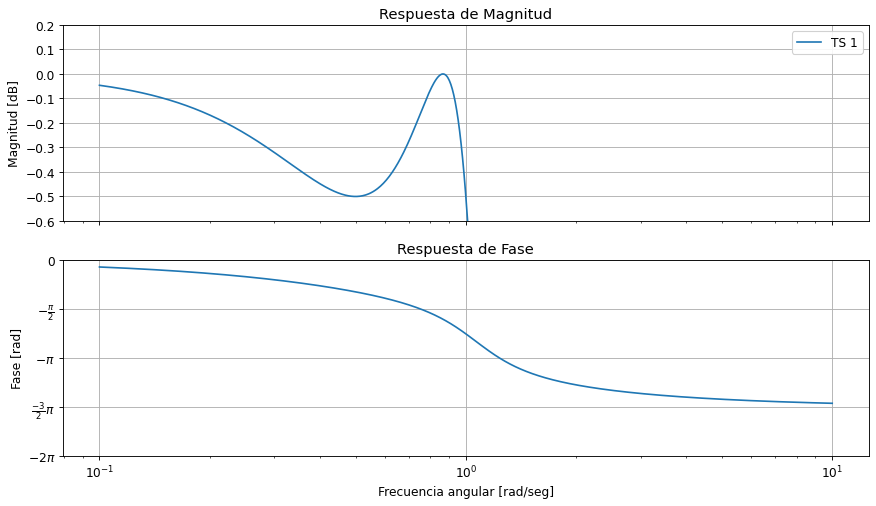

In [131]:
#Función trasnferencia
TS=sig.TransferFunction(num,den)

graficar_bode_avanzado(TS, ylim=(-0.6, 0.2))

Podemos observar que nuestra transferencia oscila entre 0 y -1dB a lo largo de la banda de paso, cumpliendo con el $\alpha_{max}$ propuesto.

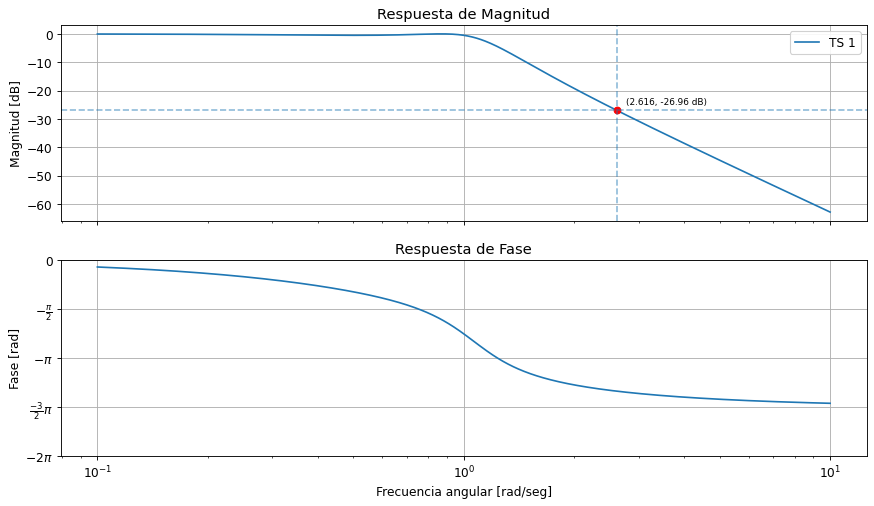

In [133]:
graficar_bode_avanzado(TS, puntos = 2.616)

Vemos también que para $\omega_{s_{LP}} = 2.616$ hubo una caida mayor a la $\alpha_{min}$ por lo que se cumple la atenuacion minima de nuestra plantilla.

### Transformacion de la plantilla

Ya verificado nuestra plantilla procedemos a volver a nuestra plantilla pasa banda usando el nucleo de transformacion.

$$
K(s) = Q \cdot \frac{s^2 + 1}{s}
$$

Para simplificar el analisis usaremos python para calcular nuestra transferencia pasa banda.

In [56]:
B=0.2

numbp, denbp = sig.lp2bp(num,den, bw=B)
numbp_pol = sp.Poly(numbp,s)
denbp_pol = sp.Poly(denbp,s)

Tsbp=sp.simplify(numbp_pol)/sp.simplify(denbp_pol)

display(Math(r'T(s) = ' + sp.latex(Tsbp)))

<IPython.core.display.Math object>

Para simplificar el analisis se ordenara en secciones de segundo orden y parametrizados por $\omega_o$ y $Q$

In [58]:
sospb = tf2sos_analog(numbp, denbp)

print_latex(a_equal_b_latex_s('T_{bp}(s)', pretty_print_SOS(sospb, displaystr=False)))
print_latex(a_equal_b_latex_s('T_{bp}(s)', pretty_print_SOS(sospb, mode='omegayq', displaystr=False)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

De esta forma nos queda nuestra transferencia de la siguiente forma

$$
T_{BP}(s) = \frac{s \cdot K_1 \cdot \frac{\omega_{0_1}}{Q_1}}{s^2 + s \cdot \frac{\omega_{0_1}}{Q_1} + \omega_{0_1}^2} \cdot \frac{s \cdot K_2 \cdot \frac{\omega_{0_2}}{Q_2}}{s^2 + s \cdot \frac{\omega_{0_2}}{Q_2} + \omega_{0_2}^2} \cdot \frac{s \cdot K_3 \cdot \frac{\omega_{0_3}}{Q_3}}{s^2 + s \cdot \frac{\omega_{0_3}}{Q_3} + \omega_{0_3}^2}
$$

Donde los parametros son:
$$
\begin{aligned}
\text{Primera Seccion}: &\hspace{1em} K_1 = 1.207 &\hspace{3em} \omega_{0_1}^2 = 1 &\hspace{3em} \frac{\omega_{0_1}}{Q_1} = \frac{1}{7.981} \\
\\
\text{Segunda Seccion}: &\hspace{1em} K_2 = 2.045 &\hspace{3em} \omega_{0_2}^2 = 0.903 &\hspace{3em} \frac{\omega_{0_2}}{Q_2} = \frac{0.903}{16.05} \\
\\
\text{Tercera Seccion}: &\hspace{1em} K_3 = 4.768 &\hspace{3em} \omega_{0_3}^2 = 1.107 &\hspace{3em} \frac{\omega_{0_3}}{Q_3} = \frac{1.107}{16.05} \\
\end{aligned}
$$

### Verificaion de la plantilla pasa banda

Ya calculado la transferencia pasa banda procedemos a verificar si esta cumple con los requisitos con nuestra plantilla

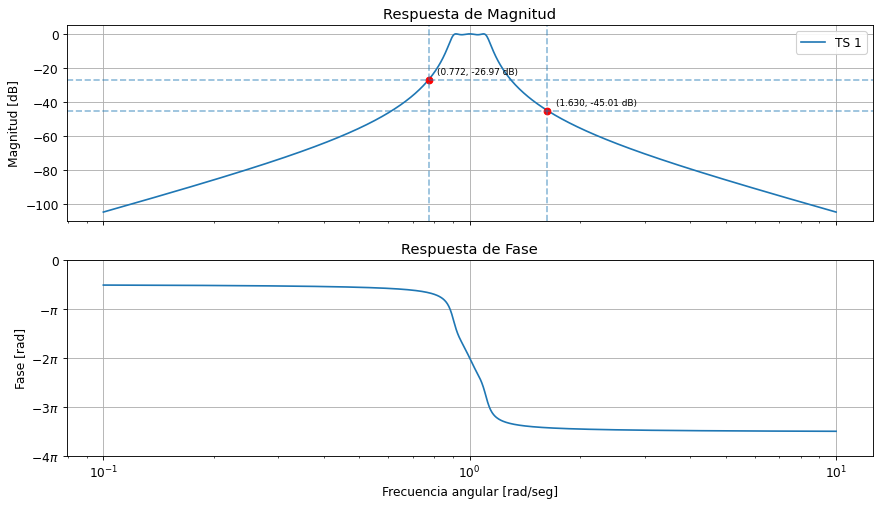

In [135]:
#Bode del pasabanda
Ts=sig.TransferFunction(numbp,denbp)

graficar_bode_avanzado(Ts, puntos=[0.772, 1.63])

Podemos apreciar que nuestra pasa banda cumple con los requesitos pedidos en la plantilla.

### Simulacion de cada seccion

Procedemos a graficar cada seccion de segundo orden

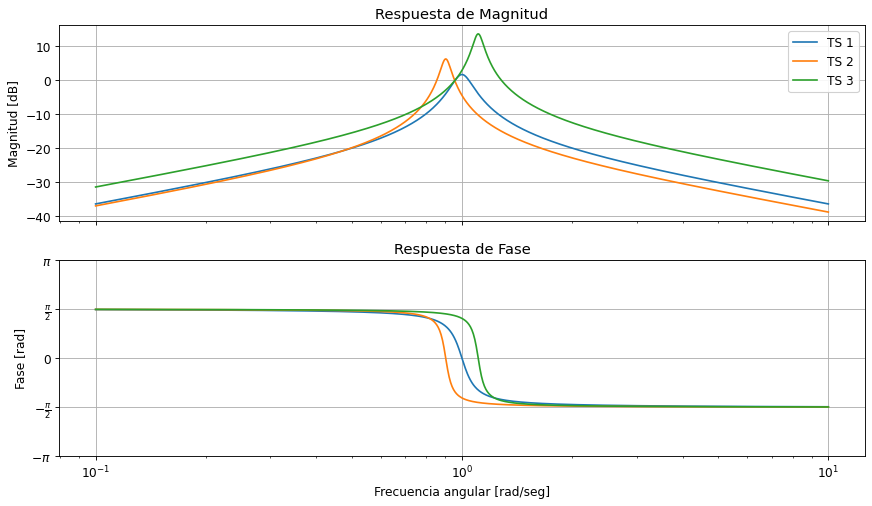

In [146]:
def normalizar_num(num):
    # Elimina ceros a la izquierda para evitar b0 = 0 en el polinomio
    num_clean = np.trim_zeros(num, "f")
    return num_clean if len(num_clean) > 0 else [0.0]


# Creamos las TransferFunction sin ceros a la izquierda en el numerador:
H1 = sig.TransferFunction(normalizar_num(sospb[0][0:3]), sospb[0][3:6])
H2 = sig.TransferFunction(normalizar_num(sospb[1][0:3]), sospb[1][3:6])
H3 = sig.TransferFunction(normalizar_num(sospb[2][0:3]), sospb[2][3:6])

graficar_bode_avanzado(TS=[H1, H2, H3])